# sc-ATAC-seq

In [7]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sn
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.cm as cm

scvi.settings.seed = 30

Seed set to 30


### Data Analysis

In [8]:
######################################################## load data
file = 'sc_atac_seq.h5ad' ### <--- data
dat1 = sc.read_h5ad(file)

######################################################## filter
sc.pp.filter_cells(dat1, min_genes = 200)
sc.pp.filter_genes(dat1, min_cells = 100)

In [9]:
dat1

AnnData object with n_obs × n_vars = 1588 × 15963
    obs: 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'peaks_snn_res.0.8', 'seurat_clusters', 'nCount_RNA', 'nFeature_RNA', 'n_genes'
    var: 'features', 'n_cells'
    obsm: 'X_umap'

In [10]:
######################################################## normalize data
dat1.layers['counts'] = dat1.X.copy()
sc.pp.normalize_total(dat1, target_sum = 10000)
sc.pp.log1p(dat1)
dat1.raw = dat1

######################################################## identify high variable genes (HVGs)
sc.pp.highly_variable_genes(dat1, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')

dat1.var.to_csv("scatacseq_HVG.csv",index=False)
dat1

AnnData object with n_obs × n_vars = 1588 × 2000
    obs: 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'peaks_snn_res.0.8', 'seurat_clusters', 'nCount_RNA', 'nFeature_RNA', 'n_genes'
    var: 'features', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    obsm: 'X_umap'
    layers: 'counts'

In [11]:
######################################################## set up and train a scVI model: set up model, initialize model, train model
scvi.model.SCVI.setup_anndata(dat1, layer = 'counts')
vae = scvi.model.SCVI(dat1)
vae.train(max_epochs=25)

######################################################## compute latent representation
vae.get_latent_representation().shape
dat1.obsm['X_scVI'] = vae.get_latent_representation()
dat1.layers['scvi_normalized'] = vae.get_normalized_expression(library_size=10000)
sc.pp.neighbors(dat1, use_rep='X_scVI') ### build a neighbor graph

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/25 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=25` reached.


In [12]:
dat1_copy = dat1.copy()

In [13]:
sc.tl.leiden(dat1, resolution = 0.0075) ### leiden clustering

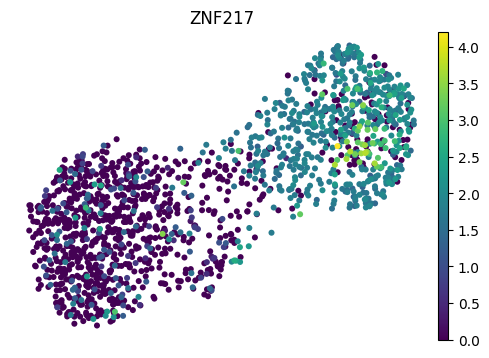

In [14]:
######################################################## plot biomarker gene
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sc.pl.umap(dat1, color=['ZNF217'], frameon=False, ax=ax, show=False) ### visualize with UMAP
plt.savefig('biomarkers_scratacseq.png')
plt.show()

In [15]:
######################################################## convert expression matrix to a dense array
expression = dat1.X
expression = expression.toarray() if hasattr(expression, "toarray") else expression
gene_names = dat1.var_names
results = []

######################################################## wilcoxon test: each gene vs rest of genes within cluster
for i, gene in enumerate(gene_names):
    gene_expr = expression[:, i]
    other_genes = np.delete(expression, i, axis=1)
    other_mean = other_genes.mean(axis=1)
    
    try:
        stat, pval = wilcoxon(gene_expr, other_mean)
    except ValueError:
        stat, pval = np.nan, np.nan
    
    ######################################################## compute log2FC
    lfc = np.log2((gene_expr.mean() + 1e-9) / (other_mean.mean() + 1e-9))
    results.append({'gene': gene, 'stat': stat, 'pval': pval, 'log2fc_vs_rest': lfc})

######################################################## apply Benjamini–Hochberg FDR correction
one_vs_rest_df = pd.DataFrame(results)
_, pvals_adj, _, _ = multipletests(one_vs_rest_df['pval'], method='fdr_bh')
one_vs_rest_df['pval_adj'] = pvals_adj

######################################################## filter by log2FC and adjusted p-value
lfc_threshold = 0.5
sig_genes_df = one_vs_rest_df[(one_vs_rest_df['pval_adj'] < 0.05) & (one_vs_rest_df['log2fc_vs_rest'].abs() > lfc_threshold)]

########################################################
one_vs_rest_df = one_vs_rest_df.sort_values('log2fc_vs_rest', ascending=False)
sig_genes_df.to_csv("significant_genes_one_vs_rest_fdr_lfc.csv", index=False)

########################################################
print(f"Number of genes: {len(one_vs_rest_df)}")
print(f"Number of significant genes (adj p < 0.05 & |log2FC| > {lfc_threshold}): {len(sig_genes_df)}")
print(one_vs_rest_df.head(20))


Number of genes: 2000
Number of significant genes (adj p < 0.05 & |log2FC| > 0.5): 1158
          gene      stat           pval  log2fc_vs_rest       pval_adj
591   PRICKLE2  170849.0  8.928603e-140        2.615687  4.932930e-139
1182      VMP1  216068.0  5.129605e-114        2.485634  1.796709e-113
1185     USP32  226284.0  1.452794e-108        2.473888  4.656391e-108
175       BMP7  292737.0   2.100754e-76        2.396214   4.460199e-76
1181    TRIM37  264944.0   3.703979e-89        2.351355   9.111880e-89
164     ZMYND8  283855.0   2.267185e-80        2.346219   5.015895e-80
166      SULF2  293908.0   6.882356e-76        2.330869   1.448917e-75
165      NCOA3  320624.0   1.296280e-64        2.290425   2.459733e-64
1552      TLE4  236150.0  1.990638e-103        2.257642  5.812082e-103
1191     BRIP1  326928.0   4.348082e-62        2.237251   8.112093e-62
1591     DACH1  243127.0  7.167588e-100        2.195505   1.990997e-99
167      PREX1  297948.0   4.000478e-74        2.170383   8.

In [16]:
######################################################## genes that are present in both lists
polyadb_list = pd.read_csv('polyadb4_TR_gene_list.csv')['gene_symbol'].tolist()
top_gene_list = pd.read_csv('significant_genes_one_vs_rest_fdr_lfc.csv')['gene'].tolist()

########################################################
shared_genes = [gene for gene in polyadb_list if gene in top_gene_list]

print(f"Number of shared genes: {len(shared_genes)}")
print("Shared genes:", shared_genes)

########################################################
shared_matched = dat1[:, shared_genes]
shared_matched.var_names_make_unique()

Number of shared genes: 1030
Shared genes: ['AADACL4', 'AASDHPPT', 'ABCA7', 'ABT1', 'ACMSD', 'ACSBG2', 'ACSL5', 'ADAM18', 'ADAM7', 'ADAMTS16', 'ADGRE1', 'ADRA2A', 'AEBP2', 'AIFM3', 'AKAP12', 'AKAP14', 'ALG10', 'ALKBH3', 'ALX1', 'ANAPC16', 'ANKLE1', 'AP2B1', 'APOBEC3D', 'APOBEC3F', 'AQP1', 'AQP10', 'AQP8', 'AREG', 'ARHGAP36', 'ARHGAP42', 'ARL14EPL', 'ARL6IP5', 'ARMC12', 'AS3MT', 'ASPHD2', 'ASXL3', 'ATCAY', 'ATOH1', 'ATP6V1B2', 'ATXN7', 'AVPR2', 'B3GNT7', 'B4GALNT4', 'BAG2', 'BCAS4', 'BCO2', 'BEX4', 'BICC1', 'BIRC5', 'BMP2', 'BMP3', 'BORA', 'BPIFB4', 'BSG', 'BTN3A1', 'BTN3A2', 'BTNL9', 'C11orf96', 'C12orf57', 'C17orf50', 'C19orf53', 'C1orf115', 'C2orf72', 'C6orf58', 'C7orf33', 'C8A', 'CABP7', 'CALD1', 'CAMSAP3', 'CASP7', 'CASQ1', 'CCDC103', 'CCDC120', 'CCDC140', 'CCDC28B', 'CCDC81', 'CCKBR', 'CCL25', 'CCNB3', 'CD19', 'CD27', 'CD4', 'CD68', 'CDC16', 'CDC45', 'CDCA7', 'CDK12', 'CDK5R1', 'CDKL5', 'CDT1', 'CELA2B', 'CENPW', 'CES4A', 'CFAP161', 'CHMP1B', 'CHODL', 'CHRND', 'CHST14', 'CHST2', '

In [17]:
shared_matched

AnnData object with n_obs × n_vars = 1588 × 1030
    obs: 'orig.ident', 'nCount_peaks', 'nFeature_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'peaks_snn_res.0.8', 'seurat_clusters', 'nCount_RNA', 'nFeature_RNA', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'features', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden'
    obsm: 'X_umap', 'X_scVI'
    layers: 'counts', 'scvi_normalized'
    obsp: 'distances', 'connectivities'

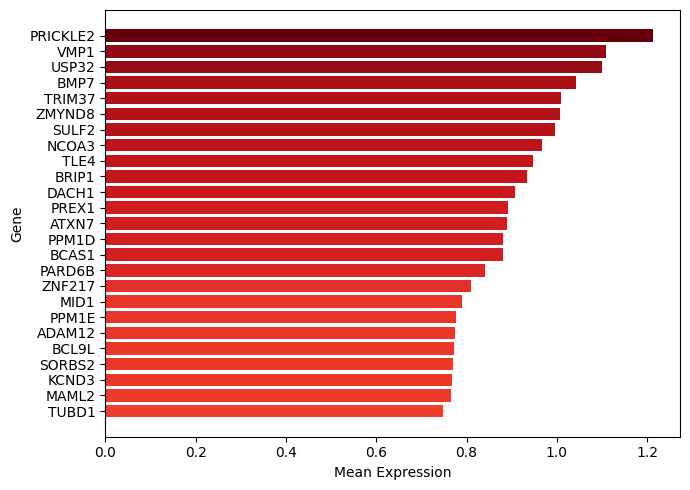

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

######################################################## convert expression matrix to a dense array
expression_shared = shared_matched.X
expression_shared = expression_shared.toarray() if hasattr(expression_shared, "toarray") else expression_shared

######################################################## compute mean expression per gene across all cells
mean_expr = expression_shared.mean(axis=0)

expr_df = pd.DataFrame({'gene': shared_matched.var_names,'mean_expression': mean_expr})

######################################################## sort by mean expression descending and pick top 25
top_expr_genes = expr_df.sort_values('mean_expression', ascending=False).head(25)

######################################################## barplot
colors = cm.Reds(top_expr_genes['mean_expression'] / top_expr_genes['mean_expression'].max())

plt.figure(figsize=(7,5))
plt.barh(top_expr_genes['gene'], top_expr_genes['mean_expression'], color=colors)
plt.xlabel('Mean Expression')
plt.ylabel('Gene')
plt.gca().invert_yaxis()  # highest expression on top
plt.tight_layout()
plt.savefig('barplot_gene_expression_scatacseq.png', dpi=300)
plt.show()